In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sales = pd.read_csv('../data/sales.csv')
sales = sales[sales["Price"] > 0].copy()

In [4]:
sales["InvoiceDate"] = pd.to_datetime(sales["InvoiceDate"])
monthly_sales = (
    sales
    .assign(
        Month=sales["InvoiceDate"].dt.to_period("M")
    )
    .groupby("Month")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique")
    )
    .reset_index()
)

monthly_sales["Month"] = (
    monthly_sales["Month"]
    .astype(str)
)

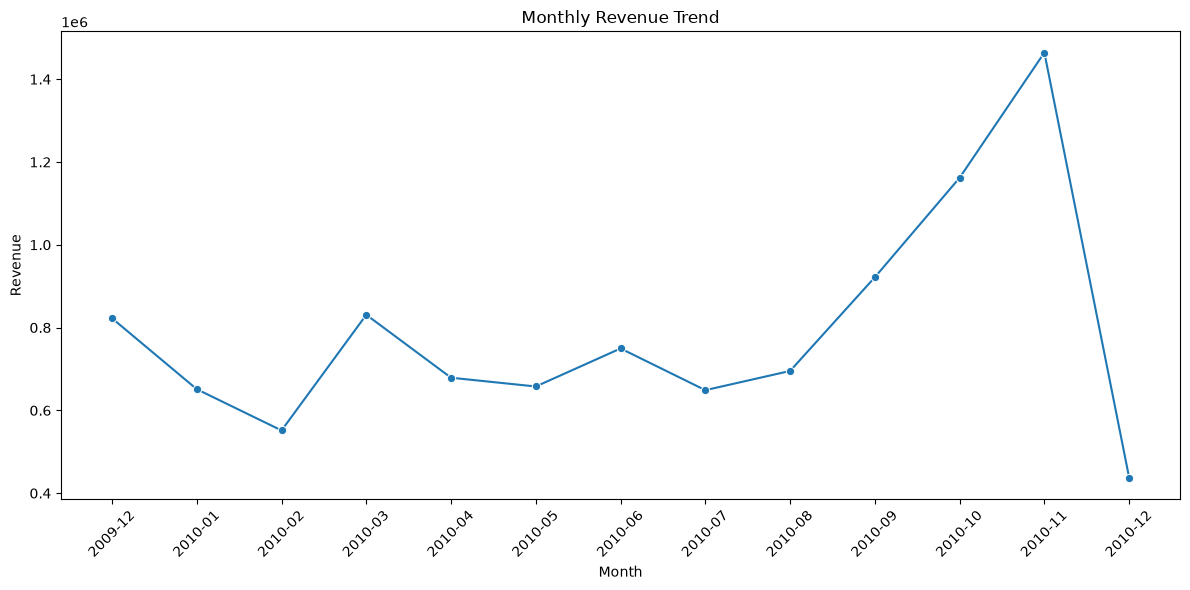

In [5]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(
    "../outputs/monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
## fig 2: Top 10 products by revenue
special_codes = ["DOT", "M", "POST"]

product_sales = sales[
    ~sales["StockCode"].isin(special_codes)
].copy()
top_products_revenue = (
    product_sales.groupby(['StockCode','Description'])
    .agg(
        Revenue = ('Revenue','sum'),
        Units = ('Quantity', 'sum')
    )
    .sort_values('Revenue',ascending=False)
    .head(10)
    .reset_index()
)

print("Top 10 Products by Revenue:")
print(top_products_revenue)

Top 10 Products by Revenue:
  StockCode                          Description    Revenue  Units
0     22423             REGENCY CAKESTAND 3 TIER  169912.76  13685
1    85123A   WHITE HANGING HEART T-LIGHT HOLDER  158305.72  58386
2     84879        ASSORTED COLOUR BIRD ORNAMENT   72890.19  45228
3     22086      PAPER CHAIN KIT 50'S CHRISTMAS    58127.30  17205
4    85099B              JUMBO BAG RED RETROSPOT   54368.82  30327
5     47566                        PARTY BUNTING   49664.12  10079
6     84347  ROTATING SILVER ANGELS T-LIGHT HLDR   47954.49  23037
7    15056N            EDWARDIAN PARASOL NATURAL   36251.10   7416
8     21621           VINTAGE UNION JACK BUNTING   36023.71   4144
9    85099F                 JUMBO BAG STRAWBERRY   35887.14  19835


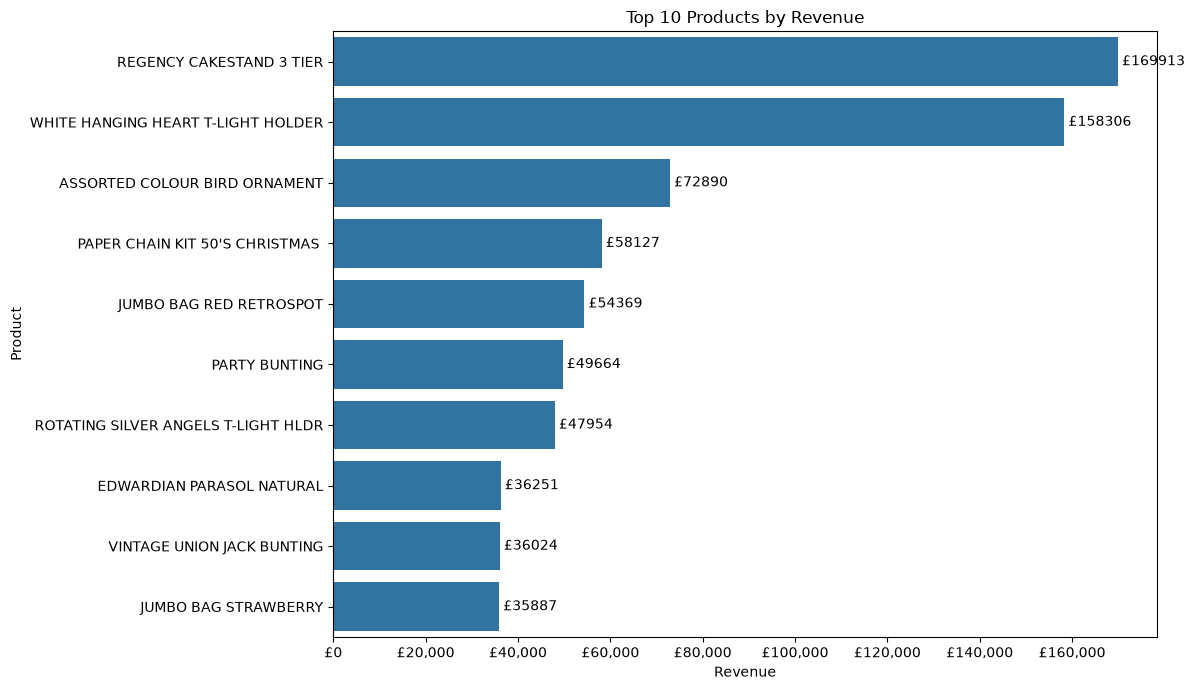

In [7]:
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_products_revenue,
    x="Revenue",
    y="Description"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt="£%.0f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../outputs/top_10_products_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
## Top 10 products by units sold
top_products_units = (
    product_sales.groupby(['StockCode','Description'])
    .agg(
        Revenue = ('Revenue','sum'),
        Units = ('Quantity','sum')
    )
    .sort_values('Units',ascending=False)
    .head(10)
    .reset_index()
)

print("Top 10 products by units sold")
print(top_products_units)

Top 10 products by units sold
  StockCode                         Description    Revenue  Units
0    85123A  WHITE HANGING HEART T-LIGHT HOLDER  158305.72  58386
1     84077   WORLD WAR 2 GLIDERS ASSTD DESIGNS   11383.97  54947
2     17003                 BROCADE RING PURSE     8922.80  48374
3     21212    PACK OF 72 RETRO SPOT CAKE CASES   24054.43  46728
4     84879       ASSORTED COLOUR BIRD ORNAMENT   72890.19  45228
5     84991         60 TEATIME FAIRY CAKE CASES   18151.40  36348
6     21977  PACK OF 60 PINK PAISLEY CAKE CASES   16187.31  31805
7    85099B             JUMBO BAG RED RETROSPOT   54368.82  30327
8     22197                SMALL POPCORN HOLDER   27022.23  29773
9     21232      STRAWBERRY CERAMIC TRINKET BOX   34411.68  27059


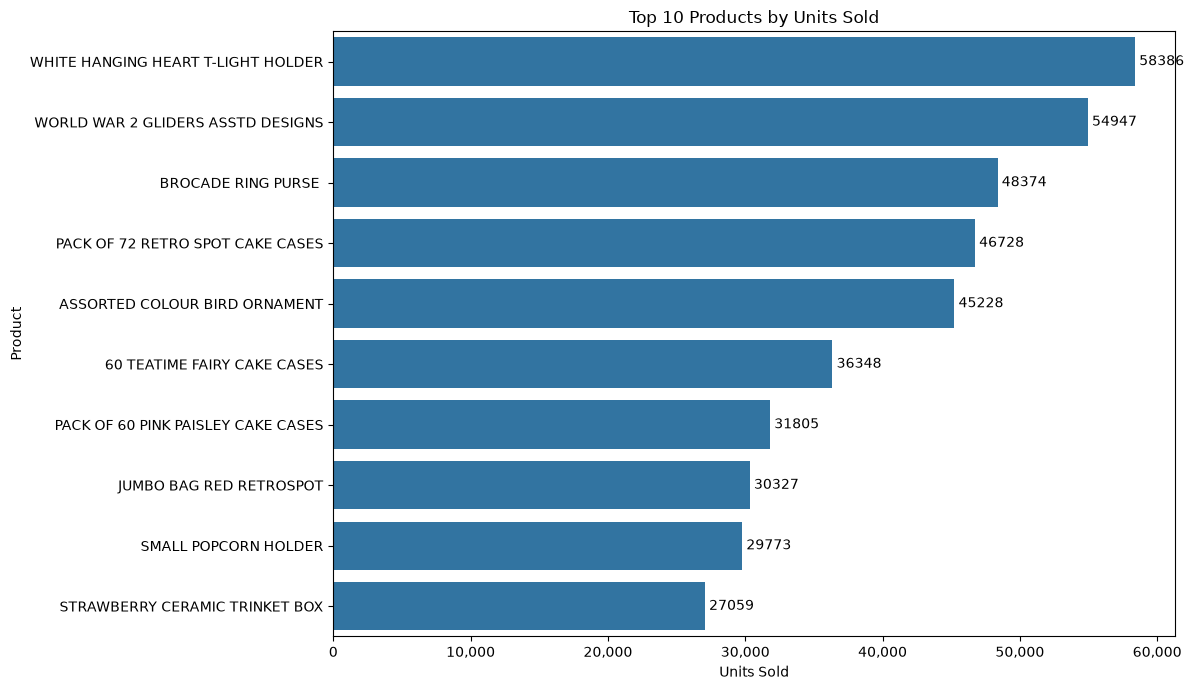

In [10]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_products_units,
    x="Units",
    y="Description"
)

plt.title("Top 10 Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f}")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../outputs/top_10_products_units.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
## Revenue by Country
top_countries = (
    product_sales.groupby('Country')
    .agg(
        Revenue = ('Revenue','sum'),
        Orders = ('Invoice','nunique'),
        Units = ('Quantity','sum')
        
    )
    .sort_values('Revenue',ascending=False)
    .head(10)
    .reset_index()
)

print("Top 10 Countries by Revenue:")
print(top_countries)

Top 10 Countries by Revenue:
          Country      Revenue  Orders    Units
0  United Kingdom  8484099.703   19108  4698733
1            EIRE   364099.450     325   193024
2     Netherlands   266061.670     124   183463
3         Germany   183020.171     328   107636
4          France   132524.440     230   162513
5         Denmark    50348.850      25   229659
6          Sweden    49490.310      65    52500
7           Spain    43082.660      61    22742
8     Switzerland    41182.390      36    22205
9       Australia    30313.350      35    20184


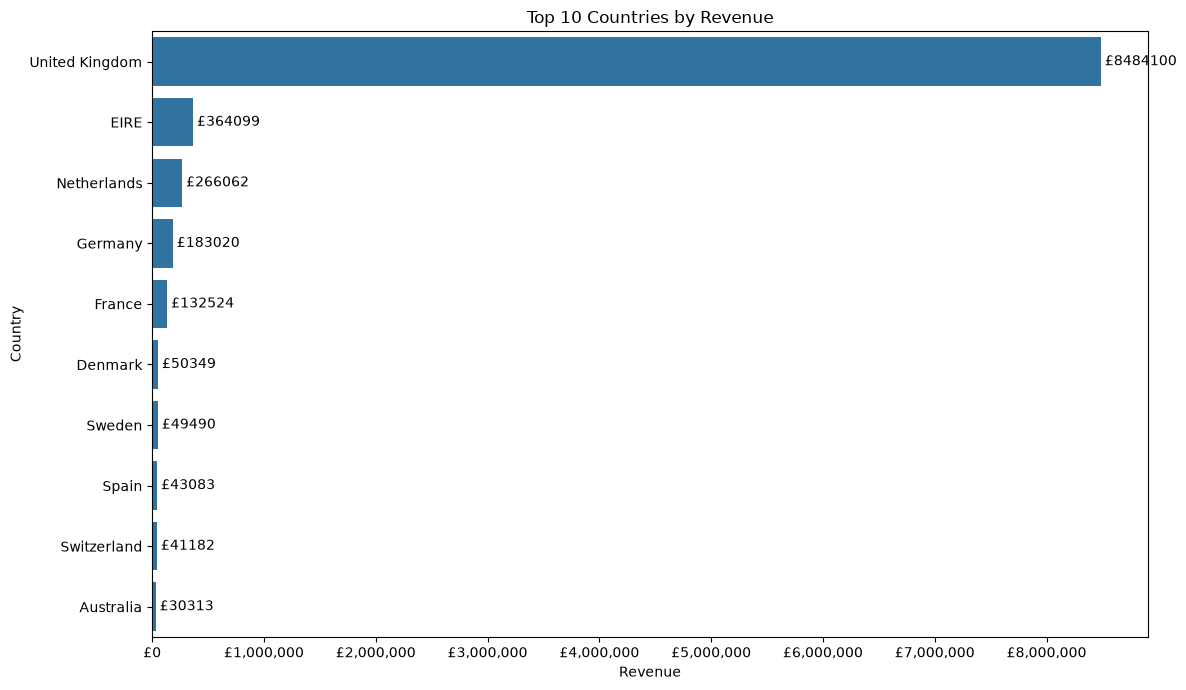

In [12]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_countries,
    x="Revenue",
    y="Country"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="£%.0f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../outputs/top_10_countries_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()